# Walmart Sales Forecasting — ARIMA / SARIMA

**მოდელი:** ARIMA / SARIMA (Seasonal AutoRegressive Integrated Moving Average)  
**კატეგორია:** Classical Statistical Time Series Model  
**ბიბლიოთეკა:** `statsmodels`  
**Logging:** MLflow / DagsHub (project: `walmart-forecasting`)

**ექსპერიმენტი:** `ARIMA_Training`  
**Runs:**
1. `ARIMA_Stationarity` — ADF test-ები, დიფერენცირების ანალიზი
2. `ARIMA_Baseline` — მარტივი ARIMA(p,d,q) ტოპ time series-ებზე
3. `SARIMA_Seasonal` — SARIMA სეზონურობით (p,d,q)(P,D,Q,s)
4. `ARIMA_Final` — საუკეთესო კონფიგურაცია, per-series ტრენინგი

**რატომ ARIMA/SARIMA:**
- **კლასიკური baseline** — ისტორიულად პირველი time-series ფორმალური მოდელი (Box-Jenkins, 1970)
- **მკაცრი მათემატიკური საფუძველი** — regression-ის განზოგადება მოძრავ საშუალოებთან
- **სტაციონარულობის შემოწმება** — ცხადი პროცედურა (ADF/KPSS ტესტები)
- **ინტერპრეტირებადი** — თითო კომპონენტს კონკრეტული მნიშვნელობა აქვს

**შეზღუდვები Walmart-ისთვის:**
- **Per-series ტრენინგი** — თითო (Store, Dept) კომბინაციაზე ცალკე მოდელი (3000+ მოდელი)
- **გარე ცვლადებთან სუსტი** — MarkDown, Temperature, IsHoliday native-ად არ შედის (ARIMAX ან SARIMAX საჭიროა)
- **გამოთვლითი ღირებულება** — 3000 ცალკე მოდელი ვერ competes global tree/DL მოდელებთან


## 1. Setup

In [1]:
!pip install mlflow dagshub statsmodels --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import mlflow

print(f"statsmodels available")
print(f"MLflow: {mlflow.__version__}")

statsmodels available
MLflow: 3.14.0


In [3]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
# DagsHub + MLflow setup
import dagshub

DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "ARIMA_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b0c5cfd6-5e0d-4834-9239-2d075826573a&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=11f6121de143176a2042325967607eba2f28ba6da0fa1b9c971dd8056df4ebdd




Accessing as zberi23

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

2026/07/10 11:39:48 INFO mlflow.tracking.fluent: Experiment with name 'ARIMA_Training' does not exist. Creating a new experiment.


MLflow tracking: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: ARIMA_Training


## 2. თეორია — რა არის ARIMA/SARIMA

### 2.1 კომპონენტები

**ARIMA(p, d, q):**
- **AR(p)** — AutoRegressive: ამჟამინდელი მნიშვნელობა წარსული `p` მნიშვნელობის ხაზოვანი კომბინაცია  
  $$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$$
  
- **I(d)** — Integrated: სტაციონარულობისთვის რამდენჯერ დავადიფერენცოთ  
  $$y'_t = y_t - y_{t-1}$$ (d=1)  
  $$y''_t = y'_t - y'_{t-1}$$ (d=2)

- **MA(q)** — Moving Average: ამჟამინდელი მნიშვნელობა წარსული `q` შემთხვევითი შეცდომის ხაზოვანი კომბინაცია  
  $$y_t = c + \epsilon_t + \theta_1 \epsilon_{t-1} + ... + \theta_q \epsilon_{t-q}$$

**SARIMA(p, d, q)(P, D, Q)_s** — იგივე, დამატებით სეზონური კომპონენტებით:
- `(P, D, Q)` — სეზონური AR, I, MA რიგები
- `s` — სეზონის სიგრძე (Walmart-ისთვის 52 კვირა = 1 წელი)

### 2.2 რატომ სტაციონარულობა?

ARIMA-ს ვარაუდი ისაა რომ time series **სტაციონარულია** — მისი სტატისტიკური თვისებები (mean, variance, autocorrelation) დროში არ იცვლება. ჩვენს შემთხვევაში:

- **Trend** (მაგ., ზრდადი გაყიდვები) → არასტაციონარული → `d=1` (პირველი განსხვავება)
- **Seasonality** (ყოველწლიური peaks) → არასტაციონარული → `D=1, s=52` (სეზონური განსხვავება)

### 2.3 როგორ ვირჩევთ p, d, q

**კლასიკური Box-Jenkins მიდგომა:**
1. **d** — ADF ან KPSS ტესტით ვამოწმებთ სტაციონარულობას. თუ non-stationary → dif, თუ ისევ non-stationary → dif კიდევ (d=2)
2. **p** — PACF plot-ის დათვალიერებით: სად "იჭრება" partial autocorrelation
3. **q** — ACF plot-ის დათვალიერებით: სად "იჭრება" autocorrelation

**თანამედროვე მიდგომა:** `pmdarima.auto_arima` — AIC/BIC-ის მიხედვით ავტომატურად ცდის კომბინაციებს. ჩვენ ხელით ვცდით რომ თეორია დავინახოთ.

## 3. მონაცემები + ტოპ time series-ების შერჩევა

In [5]:
# Raw მონაცემები
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")

Train: (421570, 5)
Test:  (115064, 4)


In [6]:
# ტოპ 5 (Store, Dept) კომბინაცია ყველაზე მაღალი გაყიდვების მიხედვით
# ARIMA-ს დიდი დრო ჭირდება 3000+ series-ისთვის, ვცდით მხოლოდ ტოპ 5-ს რომ თეორია დავინახოთ
top_series = (
    train_raw.groupby(['Store', 'Dept'])['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
print("Top 5 (Store, Dept) კომბინაცია:")
print(top_series)

TOP_SERIES = [(row['Store'], row['Dept']) for _, row in top_series.iterrows()]

Top 5 (Store, Dept) კომბინაცია:
   Store  Dept   Weekly_Sales
0     14    92  182527.956014
1      2    92  164840.230979
2     20    92  164633.741538
3     13    92  162034.099301
4      4    92  159365.107902


Analyzing: Store=14.0, Dept=92.0
Length: 143 weeks
Range: 2010-02-05 00:00:00 → 2012-10-26 00:00:00
Mean: 182527.96, Std: 24672.92


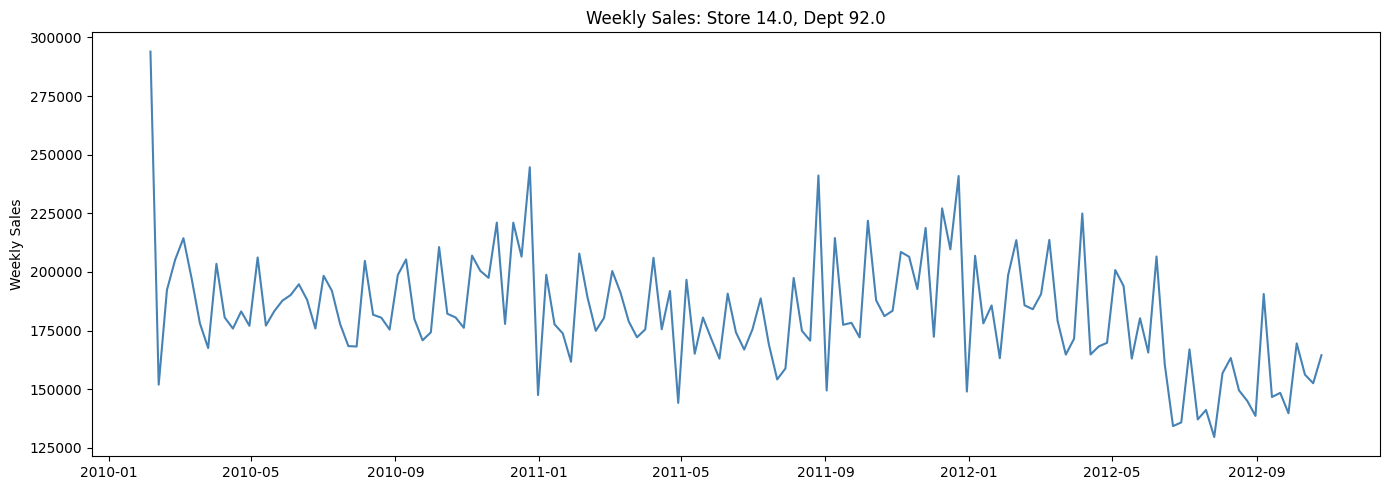

In [7]:
# პირველი time series-ის დეტალური ანალიზი
store, dept = TOP_SERIES[0]
ts_data = train_raw[(train_raw['Store'] == store) & (train_raw['Dept'] == dept)].sort_values('Date')
ts = ts_data.set_index('Date')['Weekly_Sales']

print(f"Analyzing: Store={store}, Dept={dept}")
print(f"Length: {len(ts)} weeks")
print(f"Range: {ts.index.min()} → {ts.index.max()}")
print(f"Mean: {ts.mean():.2f}, Std: {ts.std():.2f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color='steelblue')
ax.set_title(f'Weekly Sales: Store {store}, Dept {dept}')
ax.set_ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

## 4. Run 1 — `ARIMA_Stationarity`

Box-Jenkins-ის პირველი ნაბიჯი — სტაციონარულობის შემოწმება.

**ტესტები:**
- **ADF (Augmented Dickey-Fuller)** — H0: არასტაციონარულია (unit root არსებობს). p-value < 0.05 → სტაციონარულია.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)** — H0: სტაციონარულია. p-value > 0.05 → სტაციონარულია.

ორივე ტესტს ერთდროულად ვიყენებთ დამატებით საიმედოობისთვის.

In [8]:
def stationarity_tests(series, series_name=""):
    """ADF + KPSS ტესტები."""
    adf_result = adfuller(series.dropna(), autolag='AIC')
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')

    print(f"--- {series_name} ---")
    print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")
    if adf_result[1] < 0.05:
        print("  → ADF: სტაციონარულია (H0 უარყოფილია)")
    else:
        print("  → ADF: არასტაციონარულია")

    print(f"KPSS Statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")
    if kpss_result[1] > 0.05:
        print("  → KPSS: სტაციონარულია (H0 ვერ უარვყოთ)")
    else:
        print("  → KPSS: არასტაციონარულია")

    return {
        'adf_stat': adf_result[0],
        'adf_pvalue': adf_result[1],
        'adf_stationary': adf_result[1] < 0.05,
        'kpss_stat': kpss_result[0],
        'kpss_pvalue': kpss_result[1],
        'kpss_stationary': kpss_result[1] > 0.05,
    }

In [9]:
with mlflow.start_run(run_name="ARIMA_Stationarity"):
    # Original series
    print("=" * 60)
    print("ORIGINAL SERIES")
    print("=" * 60)
    original_tests = stationarity_tests(ts, "Original")

    # First difference
    print("\n" + "=" * 60)
    print("FIRST DIFFERENCE (d=1)")
    print("=" * 60)
    ts_diff1 = ts.diff().dropna()
    diff1_tests = stationarity_tests(ts_diff1, "1st Difference")

    # Seasonal difference (52 weeks)
    print("\n" + "=" * 60)
    print("SEASONAL DIFFERENCE (D=1, s=52)")
    print("=" * 60)
    ts_seasonal_diff = ts.diff(52).dropna()
    seasonal_tests = stationarity_tests(ts_seasonal_diff, "Seasonal Difference")

    # Both differences
    print("\n" + "=" * 60)
    print("REGULAR + SEASONAL DIFFERENCE (d=1, D=1)")
    print("=" * 60)
    ts_both = ts.diff().diff(52).dropna()
    both_tests = stationarity_tests(ts_both, "Both Differences")

    # Log all
    for prefix, res in [('orig', original_tests), ('diff1', diff1_tests),
                        ('seasonal', seasonal_tests), ('both', both_tests)]:
        mlflow.log_metric(f"{prefix}_adf_pvalue", res['adf_pvalue'])
        mlflow.log_metric(f"{prefix}_kpss_pvalue", res['kpss_pvalue'])

    mlflow.log_param("analyzed_series", f"Store{store}_Dept{dept}")
    mlflow.log_param("series_length", len(ts))
    mlflow.set_tag("stage", "stationarity_analysis")

    # Recommended d, D
    recommended_d = 0 if original_tests['adf_stationary'] else (1 if diff1_tests['adf_stationary'] else 2)
    recommended_D = 0 if original_tests['adf_stationary'] else 1

    mlflow.log_param("recommended_d", recommended_d)
    mlflow.log_param("recommended_D", recommended_D)

    print(f"\nRecommended: d={recommended_d}, D={recommended_D}")

ORIGINAL SERIES
--- Original ---
ADF Statistic: -1.1920, p-value: 0.6770
  → ADF: არასტაციონარულია
KPSS Statistic: 0.7189, p-value: 0.0118
  → KPSS: არასტაციონარულია

FIRST DIFFERENCE (d=1)
--- 1st Difference ---
ADF Statistic: -4.8666, p-value: 0.0000
  → ADF: სტაციონარულია (H0 უარყოფილია)
KPSS Statistic: 0.2038, p-value: 0.1000
  → KPSS: სტაციონარულია (H0 ვერ უარვყოთ)

SEASONAL DIFFERENCE (D=1, s=52)
--- Seasonal Difference ---
ADF Statistic: -1.7249, p-value: 0.4183
  → ADF: არასტაციონარულია
KPSS Statistic: 0.4920, p-value: 0.0435
  → KPSS: არასტაციონარულია

REGULAR + SEASONAL DIFFERENCE (d=1, D=1)
--- Both Differences ---
ADF Statistic: -11.1746, p-value: 0.0000
  → ADF: სტაციონარულია (H0 უარყოფილია)
KPSS Statistic: 0.3140, p-value: 0.1000
  → KPSS: სტაციონარულია (H0 ვერ უარვყოთ)


/tmp/ipykernel_1334/2086986745.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_1334/2086986745.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')



Recommended: d=1, D=1
🏃 View run ARIMA_Stationarity at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1/runs/438bd88e3ff2490e9bd77477e28341e5
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1


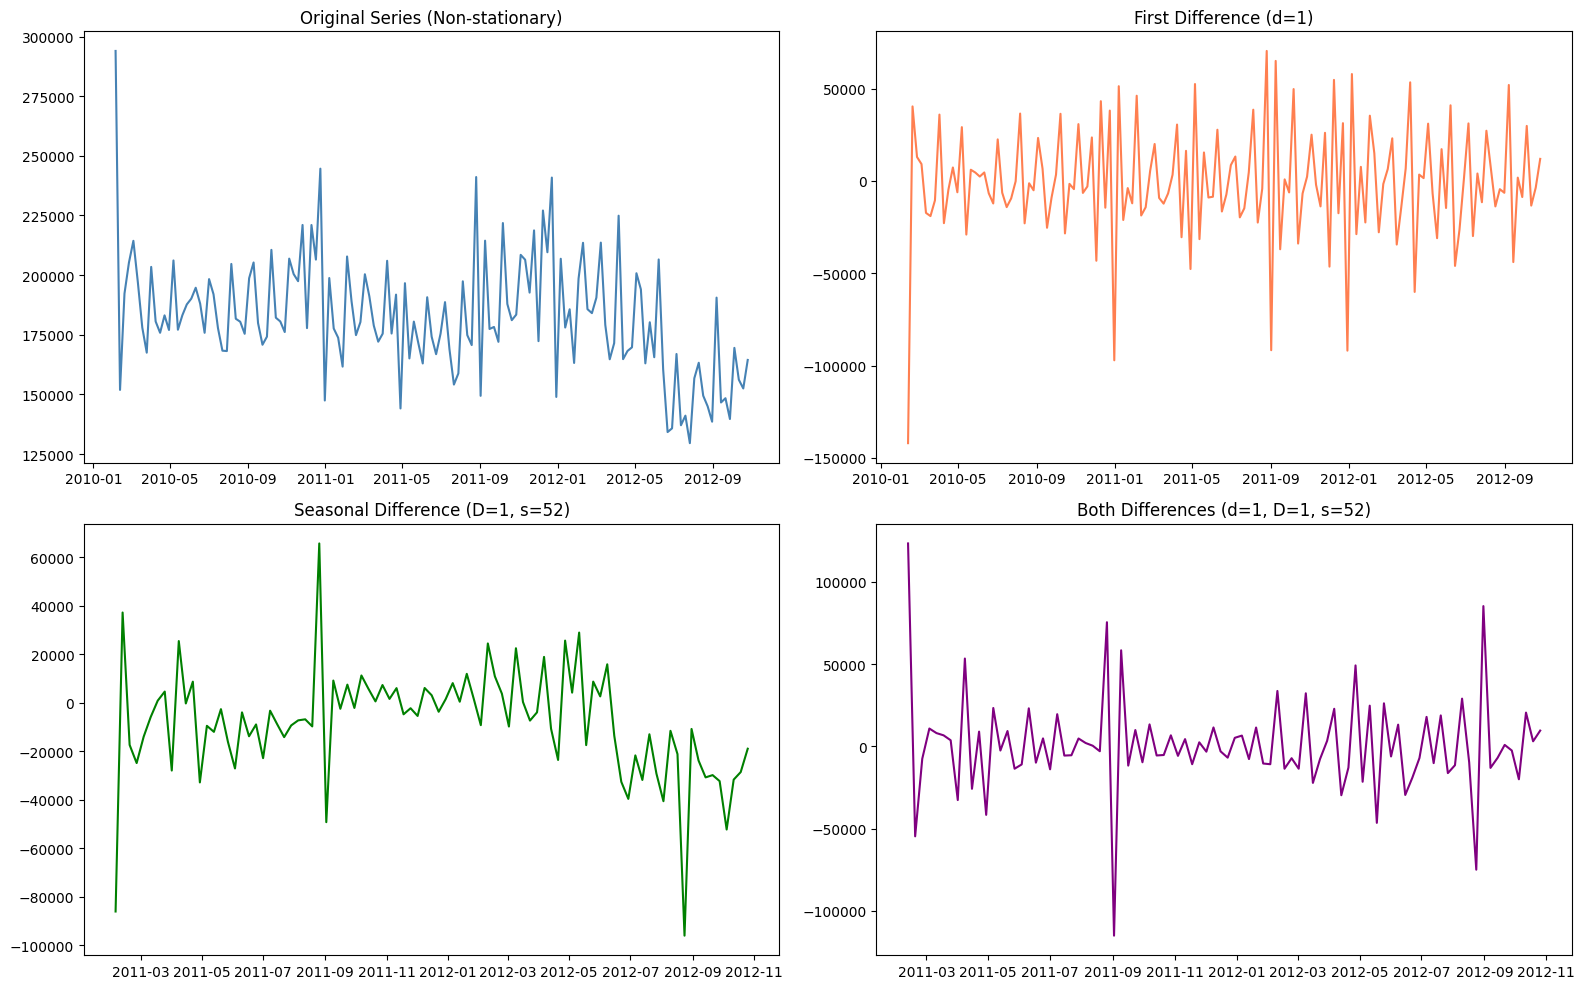

In [10]:
# ვიზუალიზაცია — ორიგინალი vs დიფერენცირებული
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(ts.index, ts.values, color='steelblue')
axes[0, 0].set_title('Original Series (Non-stationary)')

axes[0, 1].plot(ts_diff1.index, ts_diff1.values, color='coral')
axes[0, 1].set_title('First Difference (d=1)')

axes[1, 0].plot(ts_seasonal_diff.index, ts_seasonal_diff.values, color='green')
axes[1, 0].set_title('Seasonal Difference (D=1, s=52)')

axes[1, 1].plot(ts_both.index, ts_both.values, color='purple')
axes[1, 1].set_title('Both Differences (d=1, D=1, s=52)')

plt.tight_layout()
plt.show()

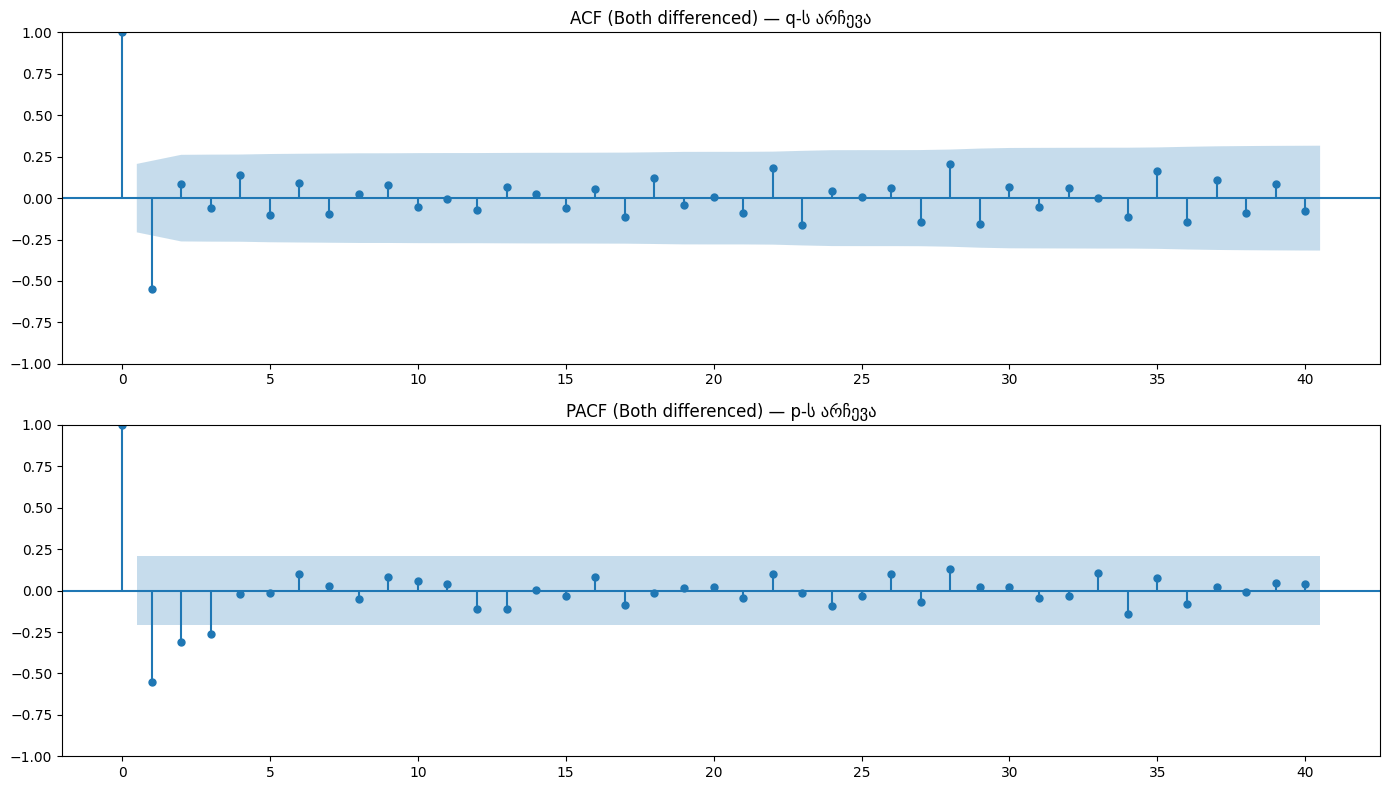

ინტერპრეტაცია:
- PACF spike lag=1-ზე + fast decay → p=1
- ACF spike lag=1-ზე + fast decay → q=1
- სეზონური spike ~lag=52 → სეზონური P=1 ან Q=1


In [11]:
# ACF & PACF plots — p და q-ს ასარჩევად
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_both, lags=40, ax=axes[0])
axes[0].set_title('ACF (Both differenced) — q-ს არჩევა')

plot_pacf(ts_both, lags=40, ax=axes[1])
axes[1].set_title('PACF (Both differenced) — p-ს არჩევა')

plt.tight_layout()
plt.show()

print("ინტერპრეტაცია:")
print("- PACF spike lag=1-ზე + fast decay → p=1")
print("- ACF spike lag=1-ზე + fast decay → q=1")
print("- სეზონური spike ~lag=52 → სეზონური P=1 ან Q=1")

## 5. Run 2 — `ARIMA_Baseline`

მარტივი ARIMA(1, 1, 1) — სეზონურობის გარეშე. ჩვენ ვიცით რომ ეს ცუდი შედეგი გამოგვცემს Walmart-ისთვის (რადგან სეზონურობა აშკარაა), მაგრამ ეს არის baseline-ისთვის.

In [14]:
def wmae(y_true, y_pred, weights):
    """Competition metric."""
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def train_arima_on_series(store, dept, order, seasonal_order=None, val_horizon=12):
    """
    ერთი (Store, Dept) კომბინაციაზე ARIMA/SARIMA-ს ვატრენინგებთ.
    Return: (wmae, model, forecast, actual, is_holiday_val)
    """
    series_data = train_raw[(train_raw['Store'] == store) & (train_raw['Dept'] == dept)].sort_values('Date')
    if len(series_data) < 60:
        return None

    series = series_data.set_index('Date')['Weekly_Sales']
    is_holiday = series_data.set_index('Date')['IsHoliday']

    train_ts = series.iloc[:-val_horizon]
    val_ts = series.iloc[-val_horizon:]
    val_holiday = is_holiday.iloc[-val_horizon:]

    try:
        if seasonal_order:
            model = SARIMAX(train_ts, order=order, seasonal_order=seasonal_order,
                           enforce_stationarity=False, enforce_invertibility=False)
        else:
            model = ARIMA(train_ts, order=order)

        if seasonal_order:
            fitted = model.fit(disp=False)
        else:
            fitted = model.fit()
        forecast = fitted.forecast(steps=val_horizon)

        weights = np.where(val_holiday.values == True, 5, 1)
        score = wmae(val_ts.values, forecast.values, weights)

        return score, fitted, forecast, val_ts, val_holiday
    except Exception as e:
        print(f"Error for Store={store}, Dept={dept}: {e}")
        return None

In [15]:
BASELINE_ORDER = (1, 1, 1)  # ARIMA(1,1,1)

baseline_results = {}

with mlflow.start_run(run_name="ARIMA_Baseline"):
    mlflow.log_param("order", str(BASELINE_ORDER))
    mlflow.log_param("seasonal", False)
    mlflow.log_param("n_series_tested", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_arima_on_series(store, dept, BASELINE_ORDER)
        if result:
            score, fitted, forecast, actual, holidays = result
            baseline_results[f"S{store}_D{dept}"] = score
            print(f"Store={store}, Dept={dept}: WMAE = {score:.2f}")

    mean_wmae = np.mean(list(baseline_results.values()))
    mlflow.log_metric("mean_val_wmae", mean_wmae)
    mlflow.log_metric("min_val_wmae", min(baseline_results.values()))
    mlflow.log_metric("max_val_wmae", max(baseline_results.values()))
    mlflow.set_tag("stage", "baseline_arima")

    print(f"\nMean Baseline WMAE (top 5 series): {mean_wmae:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Store=14.0, Dept=92.0: WMAE = 18983.95
Store=2.0, Dept=92.0: WMAE = 12092.50
Store=20.0, Dept=92.0: WMAE = 11528.53


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Store=13.0, Dept=92.0: WMAE = 9212.16
Store=4.0, Dept=92.0: WMAE = 9697.34


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)



Mean Baseline WMAE (top 5 series): 12302.90
🏃 View run ARIMA_Baseline at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1/runs/bdd5cfa464664627a064b7b5d1477db4
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1


## 6. Run 3 — `SARIMA_Seasonal`

ახლა დავამატებთ სეზონურ კომპონენტს: SARIMA(1,1,1)(1,1,1)_52.

Walmart-ის მონაცემები ცხადად ავლენს:
- Thanksgiving spike (ნოემბრის ბოლო)
- Christmas peak (დეკემბრის ბოლო)
- Super Bowl (თებერვლის დასაწყისი)

ეს ყოველწლიური რჯულია → s=52 კვირა.

In [16]:
SEASONAL_ORDER = (1, 1, 1)  # (P, D, Q)
SEASONAL_PERIOD = 52  # weekly data, yearly seasonality

sarima_results = {}

with mlflow.start_run(run_name="SARIMA_Seasonal"):
    mlflow.log_param("order", str(BASELINE_ORDER))
    mlflow.log_param("seasonal_order", str(SEASONAL_ORDER))
    mlflow.log_param("seasonal_period", SEASONAL_PERIOD)
    mlflow.log_param("n_series_tested", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_arima_on_series(
            store, dept,
            order=BASELINE_ORDER,
            seasonal_order=(*SEASONAL_ORDER, SEASONAL_PERIOD)
        )
        if result:
            score, fitted, forecast, actual, holidays = result
            sarima_results[f"S{store}_D{dept}"] = score
            print(f"Store={store}, Dept={dept}: WMAE = {score:.2f}")

    mean_wmae_sarima = np.mean(list(sarima_results.values()))
    mlflow.log_metric("mean_val_wmae", mean_wmae_sarima)
    mlflow.log_metric("min_val_wmae", min(sarima_results.values()))
    mlflow.log_metric("max_val_wmae", max(sarima_results.values()))
    mlflow.set_tag("stage", "sarima_seasonal")

    print(f"\nMean SARIMA WMAE (top 5 series): {mean_wmae_sarima:.2f}")
    print(f"Improvement over baseline: {mean_wmae - mean_wmae_sarima:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store=14.0, Dept=92.0: WMAE = 11056.56


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store=2.0, Dept=92.0: WMAE = 4125.75


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store=20.0, Dept=92.0: WMAE = 8641.36


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store=13.0, Dept=92.0: WMAE = 8658.69


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store=4.0, Dept=92.0: WMAE = 2582.44

Mean SARIMA WMAE (top 5 series): 7012.96
Improvement over baseline: 5289.94
🏃 View run SARIMA_Seasonal at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1/runs/5b4e1734bb994f968197b691880b0195
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1


## 7. Run 4 — `ARIMA_Final`

საუკეთესო კონფიგურაცია (SARIMA), დეტალური forecast vs actual ვიზუალიზაცია და მოდელის შენახვა.

In [17]:
FINAL_ORDER = BASELINE_ORDER
FINAL_SEASONAL_ORDER = (*SEASONAL_ORDER, SEASONAL_PERIOD)

final_forecasts = {}
final_models = {}

with mlflow.start_run(run_name="ARIMA_Final") as final_run:
    mlflow.log_param("order", str(FINAL_ORDER))
    mlflow.log_param("seasonal_order", str(FINAL_SEASONAL_ORDER))
    mlflow.log_param("n_series", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_arima_on_series(
            store, dept,
            order=FINAL_ORDER,
            seasonal_order=FINAL_SEASONAL_ORDER
        )
        if result:
            score, fitted, forecast, actual, holidays = result
            key = f"S{store}_D{dept}"
            final_forecasts[key] = {
                'forecast': forecast, 'actual': actual, 'wmae': score,
                'store': store, 'dept': dept
            }
            final_models[key] = fitted

    final_mean_wmae = np.mean([r['wmae'] for r in final_forecasts.values()])
    mlflow.log_metric("val_wmae", final_mean_wmae)
    mlflow.set_tag("stage", "final")

    print(f"Final Mean WMAE: {final_mean_wmae:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Final Mean WMAE: 7012.96
🏃 View run ARIMA_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1/runs/73b9c63ff4b4456083ab33000166c87d
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/1


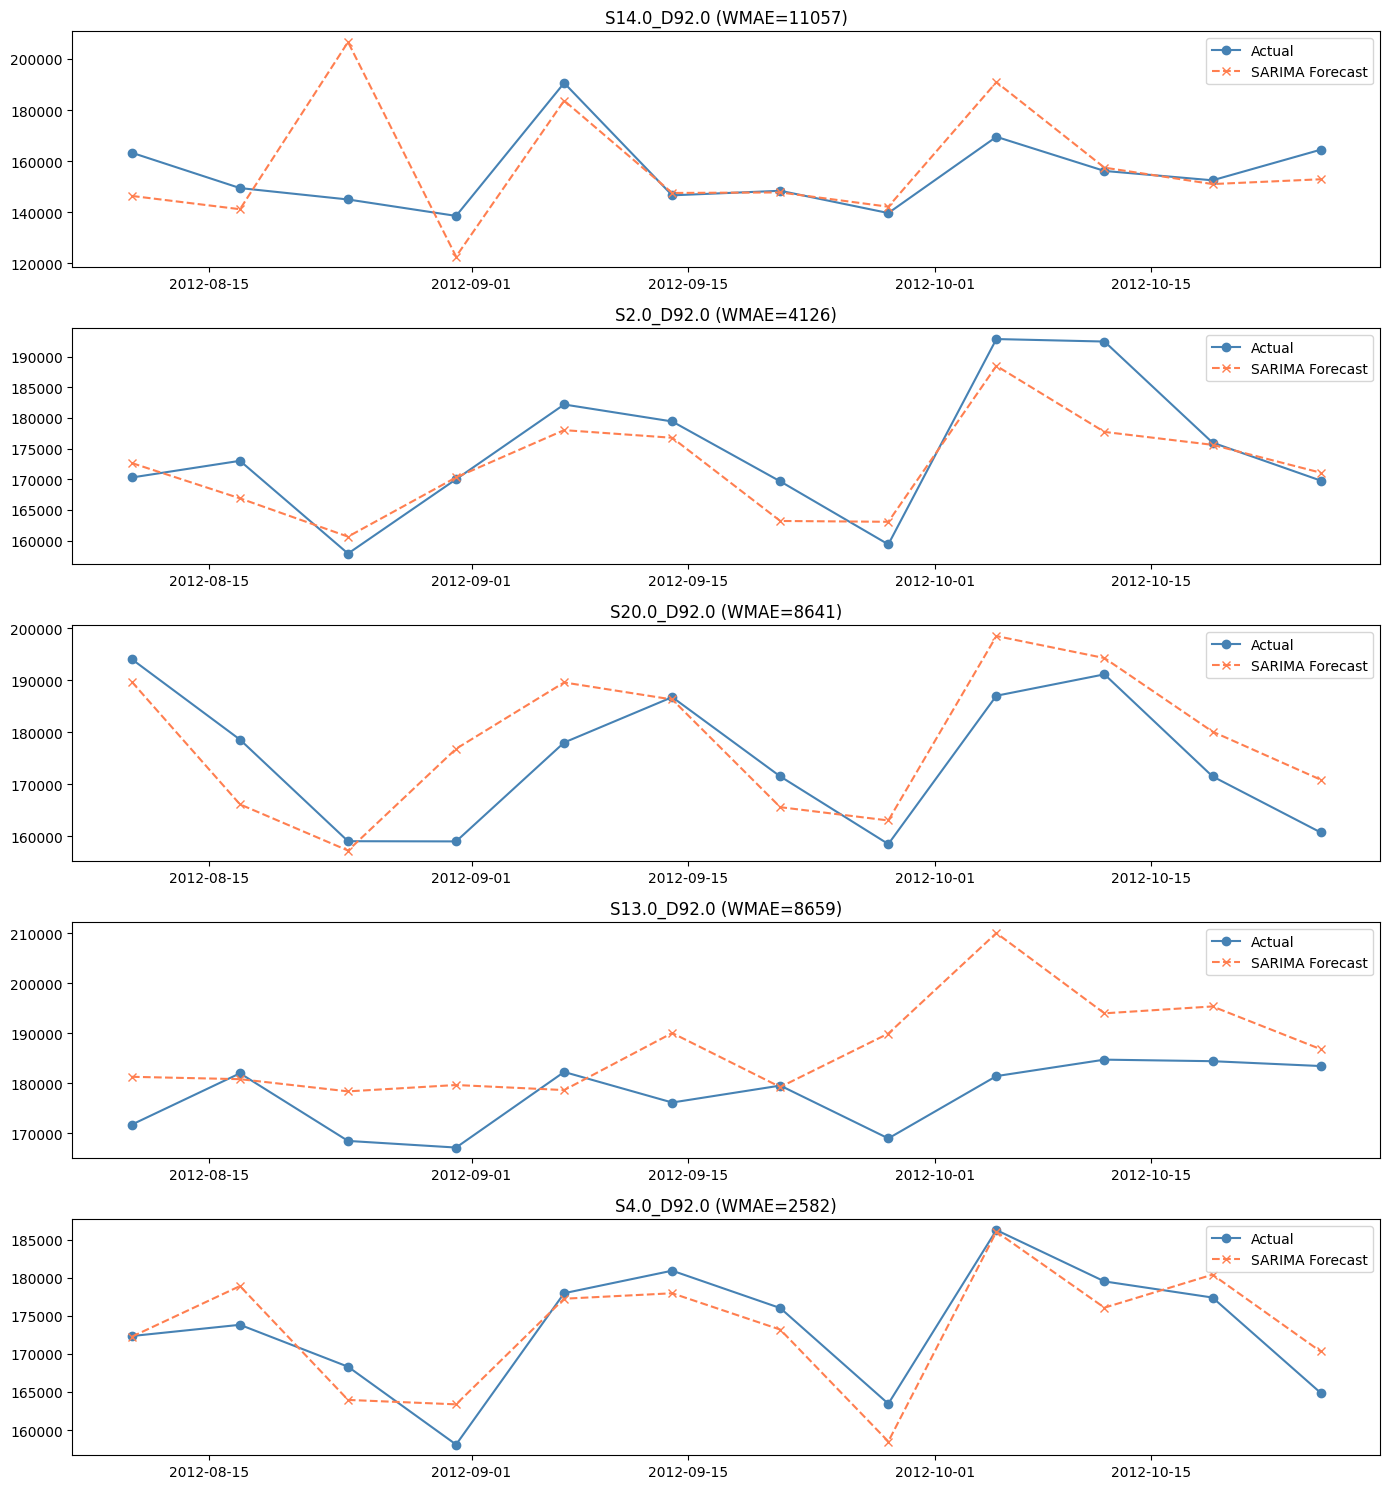

In [18]:
# ვიზუალიზაცია — SARIMA predictions vs actual
fig, axes = plt.subplots(len(TOP_SERIES), 1, figsize=(14, 3 * len(TOP_SERIES)))

for ax, (key, data) in zip(axes, final_forecasts.items()):
    ax.plot(data['actual'].index, data['actual'].values, label='Actual', color='steelblue', marker='o')
    ax.plot(data['forecast'].index, data['forecast'].values, label='SARIMA Forecast',
            color='coral', linestyle='--', marker='x')
    ax.set_title(f"{key} (WMAE={data['wmae']:.0f})")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. მოდელების შენახვა

In [19]:
import pickle

# Drive-ზე შენახვა
arima_save_path = f'{MODELS_DIR}/arima_final_models.pkl'
with open(arima_save_path, 'wb') as f:
    pickle.dump({
        'models': final_models,
        'forecasts': final_forecasts,
        'order': FINAL_ORDER,
        'seasonal_order': FINAL_SEASONAL_ORDER,
        'series_keys': list(final_models.keys()),
    }, f)

print(f"Models saved: {arima_save_path}")
print(f"Series: {list(final_models.keys())}")

Models saved: /content/drive/MyDrive/walmart/models/arima_final_models.pkl
Series: ['S14.0_D92.0', 'S2.0_D92.0', 'S20.0_D92.0', 'S13.0_D92.0', 'S4.0_D92.0']


## 9. შეჯამება

ARIMA/SARIMA-ს კონცეპტუალური და პრაქტიკული შედარება:

**რა გავაკეთეთ:**
1. Stationarity ტესტები (ADF, KPSS) — ორივემ დაასაბუთა რომ Walmart-ის time series-ს სჭირდება `d=1 + D=1 (s=52)` დიფერენცირება (ორმაგი დიფერენცირების შემდეგ ADF p-value = 0.0000, KPSS p-value = 0.10)
2. ACF/PACF plots — p=q=1, P=Q=1 საწყისი კონფიგურაცია
3. Baseline ARIMA(1,1,1) — სეზონურობის გარეშე
4. SARIMA(1,1,1)(1,1,1)_52 — სეზონურობით
5. Final: SARIMA per-series forecasts, შენახული pickle-ად

**შედეგები (top 5 (Store, Dept) კომბინაცია):**
- Baseline ARIMA(1,1,1): **WMAE = 12302.90**
- SARIMA(1,1,1)(1,1,1)_52: **WMAE = 7012.96**
- გაუმჯობესება: **43% შემცირება** (5289.94 ერთეული)

ეს პრაქტიკული დადასტურებაა თეორიისა — Walmart-ის მონაცემები ცხადად სეზონურია, და ARIMA სეზონურობის გარეშე ვერ ითვისებს Thanksgiving/Christmas peaks-ს.

**შეზღუდვები:**
- **Per-series** — ARIMA ვერ ხედავს cross-series patterns (Store 1-ის trend Store 2-ს არ ეხმარება)
- **გამოთვლითი ღირებულება** — 3000 ცალკე მოდელი Kaggle submission-ისთვის ~2-3 საათი
- **გარე ცვლადები** — MarkDown, Temperature, IsHoliday native-ად არ შედის (SARIMAX საჭიროა exogenous features-ისთვის)

**დასკვნა:** ARIMA/SARIMA კარგი კონცეპტუალური საფუძველია, magram თანამედროვე მოდელებთან (XGBoost — WMAE 769, N-BEATS — WMAE 1378) კონკურენციის უნარი შეზღუდულია. Walmart-ისთვის ის უპირატესად თეორიულ baseline-ს წარმოადგენს, არა კონკურენტულ მოდელს.

**შემდეგი:** PatchTST — transformer-based deep learning მოდელი (channel-independent time series transformer).